# 用于手写数字识别（二分类）的神经网络

在本练习中，你将使用神经网络来识别手写数字0和1。

# 大纲
- [1 - 包 ](#1)
- [2 - 神经网络](#2)
  - [2.1 问题陈述](#2.1)
  - [2.2 数据集](#2.2)
  - [2.3 模型表示](#2.3)
  - [2.4 TensorFlow模型实现](#2.4)
    - [练习1](#ex01)
  - [2.5 NumPy模型实现（NumPy中的前向传播）](#2.5)
    - [练习2](#ex02)
  - [2.6 向量化NumPy模型实现（可选）](#2.6)
    - [练习3](#ex03)
  - [2.7 恭喜！](#2.7)
  - [2.8 NumPy广播教程（可选）](#2.8)


<a name="1"></a>
## 1 - 软件包
首先，让我们运行下面的代码块，导入本次作业中所需的所有软件包。
- [numpy](https://numpy.org/)是Python进行科学计算的基础软件包。
- [matplotlib](http://matplotlib.org)是Python中一个常用的绘图库。
- [tensorflow](https://www.tensorflow.org/)是一个广受欢迎的机器学习平台。

In [1]:
import numpy as np
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
import matplotlib.pyplot as plt
from autils import *
%matplotlib widget

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)
%matplotlib --list

Available matplotlib backends: ['agg', 'auto', 'cairo', 'gtk3', 'gtk3agg', 'gtk3cairo', 'gtk4', 'gtk4agg', 'gtk4cairo', 'inline', 'ipympl', 'macosx', 'module://ipympl.backend_nbagg', 'nbagg', 'notebook', 'osx', 'pdf', 'pgf', 'ps', 'qt', 'qt5', 'qt5agg', 'qt5cairo', 'qt6', 'qtagg', 'qtcairo', 'svg', 'template', 'tk', 'tkagg', 'tkcairo', 'webagg', 'widget', 'wx', 'wx', 'wxagg', 'wxcairo']


**TensorFlow与Keras**  
TensorFlow是谷歌开发的一个机器学习软件包。2019年，谷歌将Keras集成到TensorFlow中，并发布了TensorFlow 2.0。Keras是由弗朗索瓦·肖莱（François Chollet）独立开发的一个框架，它为TensorFlow创建了一个简单的、以层为中心的接口。本课程将使用Keras接口。目前Keras已经单独出来了。

<a name="2"></a>
## 2 - 神经网络
在课程1中，你实现了逻辑回归。通过多项式回归对其进行扩展，以处理非线性边界。而对于诸如图像识别等更为复杂的场景，神经网络则更为适用。

<a name="2.1"></a>
### 2.1 问题陈述
在本练习中，你将使用神经网络识别两个手写数字：0和1。这是一个二分类任务。自动手写数字识别如今应用广泛，从识别邮件信封上的邮政编码到识别银行支票上书写的金额。在后续作业中，你将扩展这个网络，使其能够识别全部10个数字（0 - 9）。
本练习将向你展示如何将所学方法应用于这个分类任务。

<a name="2.2"></a>
### 2.2 数据集
你将从加载此任务的数据集开始。 
- 如下所示的 `load_data()` 函数将数据加载到变量 `X` 和 `y` 中。

- 该数据集包含1000个手写数字的训练样本$^1$，这里仅限于数字0和1。  
    - 每个训练样本是一个20像素×20像素的数字灰度图像。
        - 每个像素由一个浮点数表示，该浮点数指示该位置的灰度强度。
        - 20×20的像素网格被“展开”成一个400维向量。
        - 每个训练样本成为我们数据矩阵 `X` 中的一行。
        - 这就得到了一个1000×400的矩阵 `X`，其中每一行都是一个手写数字图像的训练样本。

$$X = 
\left(\begin{array}{cc} 
--- (x^{(1)}) --- \\
--- (x^{(2)}) --- \\
\vdots \\ 
--- (x^{(m)}) --- 
\end{array}\right)$$ 

- 训练集的第二部分是一个1000×1维的向量`y`，其中包含训练集的标签。
    - 如果图像是数字`0`，则`y = 0`；如果图像是数字`1`，则`y = 1`。

$^1$<sub>这是MNIST手写数字数据集的一个子集(http://yann.lecun.com/exdb/mnist/)</sub>

In [2]:
# load dataset
X, y = load_data()

<a name="toc_89367_2.2.1"></a>
#### 2.2.1 查看变量
让我们更加熟悉你的数据集。 
- 一个好的开始方式是打印出每个变量，看看它包含什么。

下面的代码打印变量`X`和`y`的元素。

In [3]:
print ('The first element of X is: ', X[0])

The first element of X is:  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+

In [4]:
print ('The first element of y is: ', y[0,0])
print ('The last element of y is: ', y[-1,0])

The first element of y is:  0
The last element of y is:  1


<a name="toc_89367_2.2.2"></a>
#### 2.2.2 检查变量的维度
熟悉数据的另一种方法是查看其维度。请打印 `X` 和 `y` 的形状，看看数据集中有多少个训练样本。

In [5]:
print ('The shape of X is: ' + str(X.shape))
print ('The shape of y is: ' + str(y.shape))

The shape of X is: (1000, 400)
The shape of y is: (1000, 1)


<a name="toc_89367_2.2.3"></a>
#### 2.2.3 数据可视化
你将从可视化训练集的一个子集开始。
- 在下面的单元格中，代码从“X”中随机选择64行，将每行映射回一个20像素×20像素的灰度图像，并将这些图像一起显示。
- 每张图像的标签显示在图像上方。

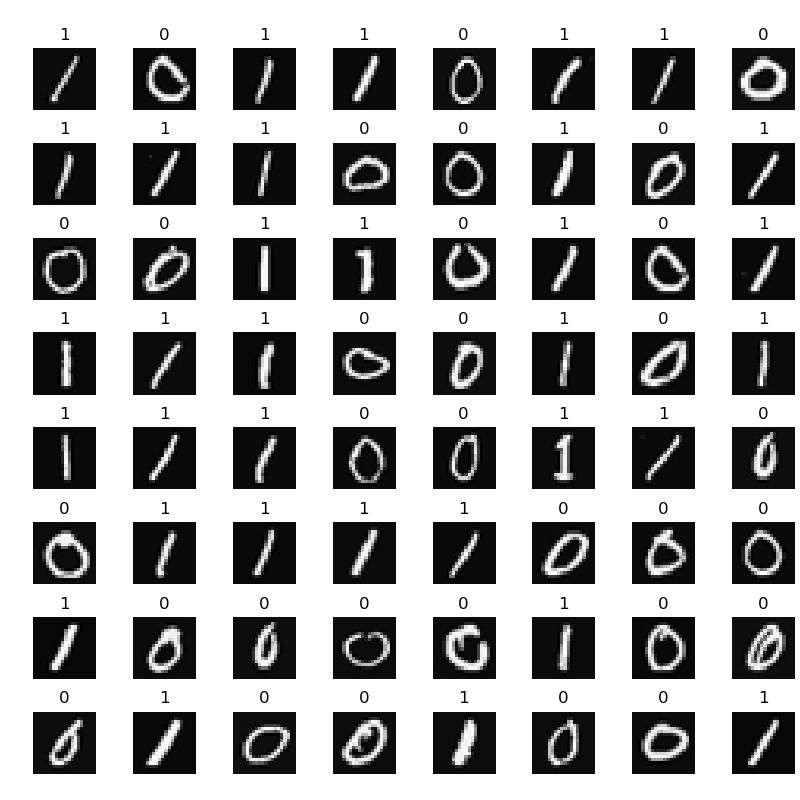

In [6]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# You do not need to modify anything in this cell

m, n = X.shape

fig, axes = plt.subplots(8,8, figsize=(8,8))
fig.tight_layout(pad=0.1, rect=[0, 0, 1, 0.95])

for i,ax in enumerate(axes.flat):
    # Select random indices
    random_index = np.random.randint(m)
    
    # Select rows corresponding to the random indices and
    # reshape the image
    X_random_reshaped = X[random_index].reshape((20,20)).T
    
    # Display the image
    ax.imshow(X_random_reshaped, cmap='gray')
    
    # Display the label above the image
    ax.set_title(y[random_index,0])
    ax.set_axis_off()

<a name="2.3"></a>
### 2.3 模型表示
你将在本次作业中使用的神经网络如下图所示。 
- 该网络有3个具有Sigmoid激活函数的全连接层。
  - 请记住，我们的输入是数字图像的像素值。
  - 由于图像大小为$20\times20$，这就给我们提供了$400$个输入。 
    
<img src="images/C2_W1_Assign1.PNG" width="500" height="400">

- 这些参数的维度是为一个神经网络设定的，该网络第1层有$25$个单元，第2层有$15$个单元，第3层有$1$个输出单元。
    - 回想一下，这些参数的维度是这样确定的：
        - 如果网络某一层有$s_{in}$个单元，下一层有$s_{out}$个单元，那么
            - $W$的维度将是$s_{in} \times s_{out}$。
            - $b$将是一个有$s_{out}$个元素的向量。
    - 因此，`W`和`b`的形状是：
        - 第1层：`W1`的形状是(400, 25)，`b1`的形状是(25,)。
        - 第2层：`W2`的形状是(25, 15)，`b2`的形状是(15,)。
        - 第3层：`W3`的形状是(15, 1)，`b3`的形状是(1,)。
>**注意**：偏置向量`b`可以表示为一维(n,)或二维(n,1)数组。TensorFlow使用一维表示，本实验也将遵循这一惯例。 
               

<a name="2.4"></a>
### 2.4 TensorFlow模型实现


TensorFlow模型是逐层构建的。系统会为您计算某一层的输入维度（如上述的$s_{in}$）。您需要指定某一层的*输出维度*，而这将决定下一层的输入维度。第一层的输入维度由下面`model.fit`语句中指定的输入数据大小得出。 

>**注意**：也可以添加一个输入层来指定第一层的输入维度。例如：  
```python
tf.keras.Input(shape=(400,)),    #指定输入形状
```  

<a name="ex01"></a>
### Exercise 1

下面，使用Keras的[Sequential模型](https://keras.io/guides/sequential_model/)和具有sigmoid激活函数的[全连接层](https://keras.io/api/layers/core_layers/dense/)来构建上述网络。

In [7]:
# UNQ_C1
# GRADED CELL: Sequential model

model = Sequential(
    [               
        tf.keras.Input(shape=(400,)),    #specify input size
        ### START CODE HERE ### 
        Dense(25, activation='sigmoid'),
        Dense(15, activation='sigmoid'),
        Dense(1, activation='sigmoid'),
        ### END CODE HERE ### 
    ], name = "my_model" 
)                            


In [8]:
model.summary()

Model: "my_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 25)             │        10,025 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,431 (40.75 KB)

 Trainable params: 10,431 (40.75 KB)

 Non-trainable params: 0 (0.00 B)

<details>
  <summary><font size="3" color="darkgreen"><b>Expected Output (Click to Expand) </b></font></summary>
The `model.summary()` function displays a useful summary of the model. Because we have specified an input layer size, the shape of the weight and bias arrays are determined and the total number of parameters per layer can be shown. Note, the names of the layers may vary as they are auto-generated.  
    
    
```
Model: "my_model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
=================================================================
dense (Dense)                (None, 25)                10025     
_________________________________________________________________
dense_1 (Dense)              (None, 15)                390       
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 16        
=================================================================
Total params: 10,431
Trainable params: 10,431
Non-trainable params: 0
_________________________________________________________________
```

<details>
  <summary><font size="3" color="darkgreen"><b>Click for hints</b></font></summary>
如讲座中所述:

```python
model = Sequential(                      
    [                                   
        tf.keras.Input(shape=(400,)),    # specify input size (optional)
        Dense(25, activation='sigmoid'), 
        Dense(15, activation='sigmoid'), 
        Dense(1,  activation='sigmoid')  
    ], name = "my_model"                                    
)                                       
``` 

In [9]:
# UNIT TESTS
from public_tests import * 
test_c1(model)

All tests passed!


摘要中显示的参数数量与如下所示的权重和偏置数组中的元素数量相对应。

In [10]:
L1_num_params = 400 * 25 + 25  # W1 parameters  + b1 parameters
L2_num_params = 25 * 15 + 15   # W2 parameters  + b2 parameters
L3_num_params = 15 * 1 + 1     # W3 parameters  + b3 parameters
print("L1 params = ", L1_num_params, ", L2 params = ", L2_num_params, ",  L3 params = ", L3_num_params )

L1 params =  10025 , L2 params =  390 ,  L3 params =  16


让我们进一步检查权重，以验证TensorFlow生成的维度与我们上面计算的维度相同。

In [11]:
[layer1, layer2, layer3] = model.layers

In [12]:
#### Examine Weights shapes
W1,b1 = layer1.get_weights()
W2,b2 = layer2.get_weights()
W3,b3 = layer3.get_weights()
print(f"W1 shape = {W1.shape}, b1 shape = {b1.shape}")
print(f"W2 shape = {W2.shape}, b2 shape = {b2.shape}")
print(f"W3 shape = {W3.shape}, b3 shape = {b3.shape}")

W1 shape = (400, 25), b1 shape = (25,)
W2 shape = (25, 15), b2 shape = (15,)
W3 shape = (15, 1), b3 shape = (1,)


**Expected Output**
```
W1 shape = (400, 25), b1 shape = (25,)  
W2 shape = (25, 15), b2 shape = (15,)  
W3 shape = (15, 1), b3 shape = (1,)
```

`xx.get_weights`返回一个NumPy数组。也可以直接以张量形式访问权重。注意最后一层中张量的形状。

In [13]:
print(model.layers[2].weights)

[<KerasVariable shape=(15, 1), dtype=float32, path=my_model/dense_2/kernel>, <KerasVariable shape=(1,), dtype=float32, path=my_model/dense_2/bias>]


以下代码将定义一个损失函数，并运行梯度下降算法，使模型的权重与训练数据相拟合。下周将对此进行更详细的解释。

In [14]:
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),  #二元交叉熵损失函数
    optimizer=tf.keras.optimizers.Adam(0.001),
)

model.fit(
    X,y,
    epochs=20
)

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 618us/step - loss: 0.7470
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 519us/step - loss: 0.5698
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 544us/step - loss: 0.4276
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 468us/step - loss: 0.3141
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 507us/step - loss: 0.2311
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 453us/step - loss: 0.1723
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 459us/step - loss: 0.1367
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1111  
Epoch 9/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 421us/step - loss: 0.0894
Epoch 10/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 473us/step - loss: 0.0823
Epoch 11/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 467us/step - loss: 0.0630
Epoch 12/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 430us/step - loss: 0.0542
Epoch 13/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 475us/step - loss: 0.0484
Epoch 14/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 449us/step - loss: 0.0451
Epoch 15/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 469us/step - lo

要在示例上运行模型进行预测，请使用[Keras `predict`](https://www.tensorflow.org/api_docs/python/tf/keras/Model)。`predict` 的输入是一个数组，因此单个示例会被重塑为二维。

In [15]:
prediction = model.predict(X[0].reshape(1,400))  # a zero
print(f" predicting a zero: {prediction}")
prediction = model.predict(X[500].reshape(1,400))  # a one
print(f" predicting a one:  {prediction}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
 predicting a zero: [[0.0162781]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
 predicting a one:  [[0.97541845]]


该模型的输出被解释为一种概率。在上述第一个例子中，输入为0。模型预测输入为1的概率几乎为0。在第二个例子中，输入为1。模型预测输入为1的概率几乎为1。与逻辑回归的情况一样，将该概率与一个阈值进行比较，以做出最终预测。

In [16]:
if prediction >= 0.5:
    yhat = 1
else:
    yhat = 0
print(f"prediction after threshold: {yhat}")

prediction after threshold: 1


让我们对比一下64个随机数字样本的预测结果与标签。这需要一些时间来运行。

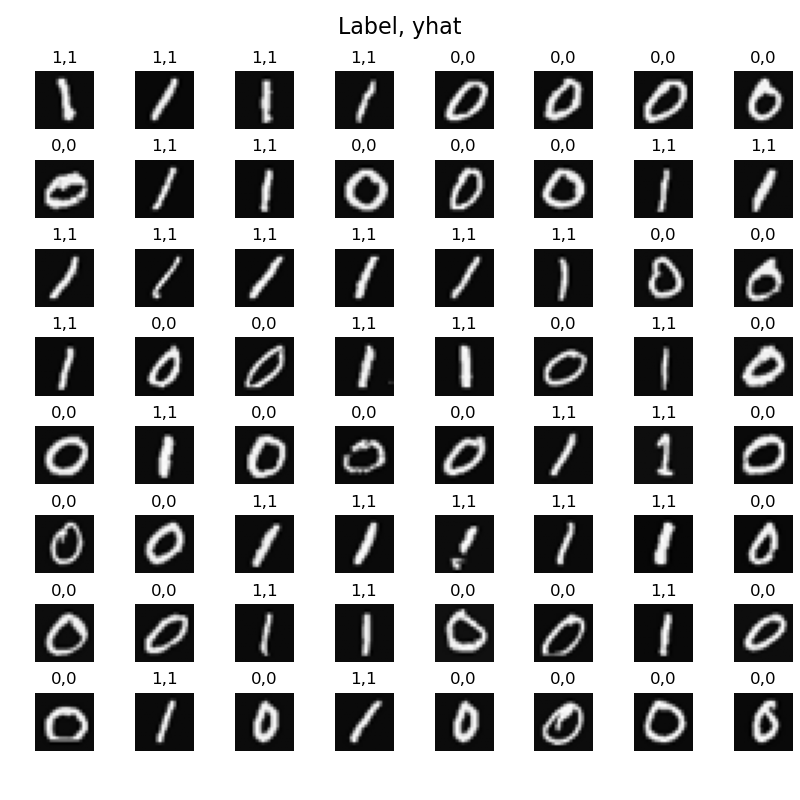

In [17]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# You do not need to modify anything in this cell

m, n = X.shape

fig, axes = plt.subplots(8,8, figsize=(8,8))
fig.tight_layout(pad=0.1,rect=[0, 0.03, 1, 0.92]) #[left, bottom, right, top]

for i,ax in enumerate(axes.flat):
    # Select random indices
    random_index = np.random.randint(m)
    
    # Select rows corresponding to the random indices and
    # reshape the image
    X_random_reshaped = X[random_index].reshape((20,20)).T
    
    # Display the image
    ax.imshow(X_random_reshaped, cmap='gray')
    
    # Predict using the Neural Network
    prediction = model.predict(X[random_index].reshape(1,400), verbose=0)
    if prediction >= 0.5:
        yhat = 1
    else:
        yhat = 0
    
    # Display the label above the image
    ax.set_title(f"{y[random_index,0]},{yhat}")
    ax.set_axis_off()
fig.suptitle("Label, yhat", fontsize=16)
plt.show()

<a name="2.5"></a>
### 2.5 NumPy模型实现（NumPy中的前向传播）
如课堂所述，可以使用NumPy构建自己的全连接层。然后可以利用这一点构建一个多层神经网络。

<img src="images/C2_W1_dense2.PNG" width="600" height="450">


<a name="ex02"></a>
### Exercise 2
下面，构建一个全连接层子程序。课堂示例中使用了一个for循环来遍历层中的每个单元（`j`），并对该单元的权重（`W[:,j]`）进行点积运算，再加上该单元的偏置（`b[j]`）以形成`z`。然后对该结果应用激活函数`g(z)`。本节不会使用可选课程中描述的一些矩阵运算。这些将在后面的章节中探讨。 

In [18]:
# UNQ_C2
# GRADED FUNCTION: my_dense

def my_dense(a_in, W, b, g):
    """
    Computes dense layer
    Args:
      a_in (ndarray (n, )) : Data, 1 example 
      W    (ndarray (n,j)) : Weight matrix, n features per unit, j units
      b    (ndarray (j, )) : bias vector, j units  
      g    activation function (e.g. sigmoid, relu..)
    Returns
      a_out (ndarray (j,))  : j units
    """
    units = W.shape[1]
    a_out = np.zeros(units)
### START CODE HERE ### 
    for j in range(units):
        w = W[:,j]
        z = np.dot(w, a_in) + b[j]
        a_out[j] = g(z)
        
### END CODE HERE ### 
    return(a_out)


In [19]:
# Quick Check
x_tst = 0.1*np.arange(1,3,1).reshape(2,)  # (1 examples, 2 features)
W_tst = 0.1*np.arange(1,7,1).reshape(2,3) # (2 input features, 3 output features)
b_tst = 0.1*np.arange(1,4,1).reshape(3,)  # (3 features)
A_tst = my_dense(x_tst, W_tst, b_tst, sigmoid)
print(A_tst)

[0.54735762 0.57932425 0.61063923]


**Expected Output**
```
[0.54735762 0.57932425 0.61063923]
```

<details>
  <summary><font size="3" color="darkgreen"><b>Click for hints</b></font></summary>
As described in the lecture:
    
```python
def my_dense(a_in, W, b, g):
    """
    Computes dense layer
    Args:
      a_in (ndarray (n, )) : Data, 1 example 
      W    (ndarray (n,j)) : Weight matrix, n features per unit, j units
      b    (ndarray (j, )) : bias vector, j units  
      g    activation function (e.g. sigmoid, relu..)
    Returns
      a_out (ndarray (j,))  : j units
    """
    units = W.shape[1]
    a_out = np.zeros(units)
    for j in range(units):             
        w =                            # Select weights for unit j. These are in column j of W
        z =                            # dot product of w and a_in + b
        a_out[j] =                     # apply activation to z
    return(a_out)
```
   
    
<details>
  <summary><font size="3" color="darkgreen"><b>Click for more hints</b></font></summary>

    
```python
def my_dense(a_in, W, b, g):
    """
    Computes dense layer
    Args:
      a_in (ndarray (n, )) : Data, 1 example 
      W    (ndarray (n,j)) : Weight matrix, n features per unit, j units
      b    (ndarray (j, )) : bias vector, j units  
      g    activation function (e.g. sigmoid, relu..)
    Returns
      a_out (ndarray (j,))  : j units
    """
    units = W.shape[1]
    a_out = np.zeros(units)
    for j in range(units):             
        w = W[:,j]                     
        z = np.dot(w, a_in) + b[j]     
        a_out[j] = g(z)                
    return(a_out)
``` 

In [20]:
# UNIT TESTS
test_c2(my_dense)

All tests passed!


下面的代码单元利用上述 `my_dense` 子程序构建了一个三层神经网络。

In [21]:
def my_sequential(x, W1, b1, W2, b2, W3, b3):
    a1 = my_dense(x,  W1, b1, sigmoid)
    a2 = my_dense(a1, W2, b2, sigmoid)
    a3 = my_dense(a2, W3, b3, sigmoid)
    return(a3)

我们可以从TensorFlow复制训练好的权重和偏差。

In [22]:
W1_tmp,b1_tmp = layer1.get_weights()
W2_tmp,b2_tmp = layer2.get_weights()
W3_tmp,b3_tmp = layer3.get_weights()

In [23]:
# make predictions
prediction = my_sequential(X[0], W1_tmp, b1_tmp, W2_tmp, b2_tmp, W3_tmp, b3_tmp )
if prediction >= 0.5:
    yhat = 1
else:
    yhat = 0
print( "yhat = ", yhat, " label= ", y[0,0])
prediction = my_sequential(X[500], W1_tmp, b1_tmp, W2_tmp, b2_tmp, W3_tmp, b3_tmp )
if prediction >= 0.5:
    yhat = 1
else:
    yhat = 0
print( "yhat = ", yhat, " label= ", y[500,0])

yhat =  0  label=  0
yhat =  1  label=  1


运行以下单元格，查看Numpy模型和TensorFlow模型的预测结果。这需要一些时间来运行。

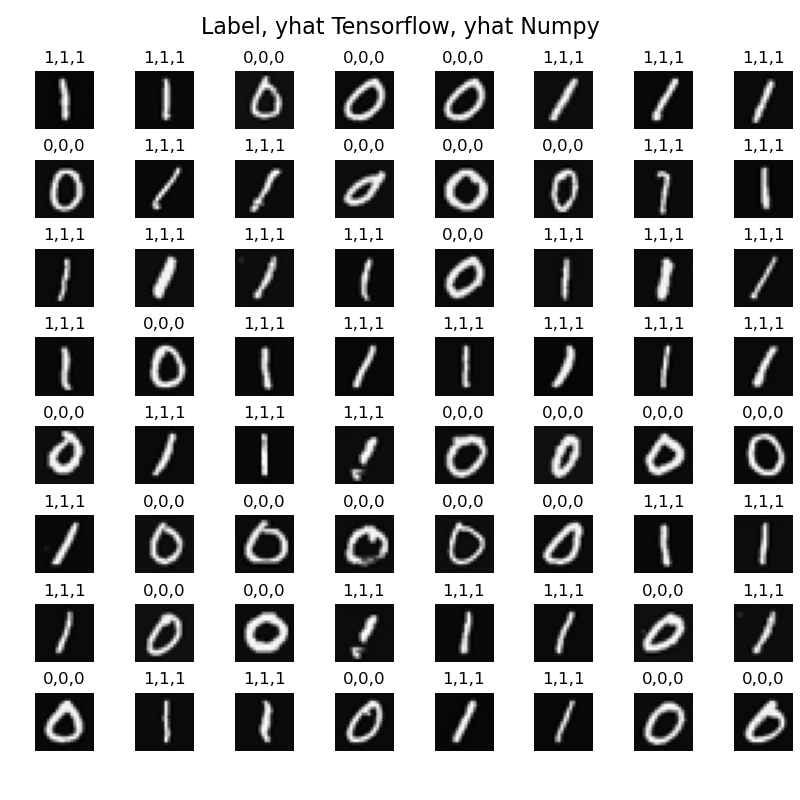

In [24]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# You do not need to modify anything in this cell

m, n = X.shape

fig, axes = plt.subplots(8,8, figsize=(8,8))
fig.tight_layout(pad=0.1,rect=[0, 0.03, 1, 0.92]) #[left, bottom, right, top]

for i,ax in enumerate(axes.flat):
    # Select random indices
    random_index = np.random.randint(m)
    
    # Select rows corresponding to the random indices and
    # reshape the image
    X_random_reshaped = X[random_index].reshape((20,20)).T
    
    # Display the image
    ax.imshow(X_random_reshaped, cmap='gray')

    # Predict using the Neural Network implemented in Numpy
    my_prediction = my_sequential(X[random_index], W1_tmp, b1_tmp, W2_tmp, b2_tmp, W3_tmp, b3_tmp )
    my_yhat = int((my_prediction >= 0.5)[0])

    # Predict using the Neural Network implemented in Tensorflow
    tf_prediction = model.predict(X[random_index].reshape(1,400), verbose=0)
    
    tf_yhat = int((tf_prediction >= 0.5)[0][0])
    
    # Display the label above the image
    ax.set_title(f"{y[random_index,0]},{tf_yhat},{my_yhat}")
    ax.set_axis_off() 
fig.suptitle("Label, yhat Tensorflow, yhat Numpy", fontsize=16)
plt.show()

<a name="2.6"></a>
### 2.6 向量化NumPy模型实现（可选）
可选课程介绍了可用于加快计算速度的向量和矩阵运算。  
下面描述了一种层运算，它针对给定的输入示例计算某一层中所有单元的输出：

<img src="images/C2_W1_VectorMatrix.PNG" width="600" height="450">

我们可以使用上面的示例`X`以及`W1`、`b1`参数来演示这一点。我们使用`np.matmul`进行矩阵乘法。请注意，正如上面的图表所示，x和W的维度必须兼容。

In [25]:
x = X[0].reshape(-1,1)         # column vector (400,1)
z1 = np.matmul(x.T,W1) + b1.reshape(-1,25)    # (1,400)(400,25) = (1,25)
a1 = sigmoid(z1)
print(a1.shape)

(1, 25)


你可以更进一步，通过一次矩阵 - 矩阵运算计算所有示例的所有单元。

<img src="images/C2_W1_MatrixMatrix.PNG" width="600" height="450">
完整的运算为 $\mathbf{Z}=\mathbf{XW}+\mathbf{b}$。这将利用NumPy广播机制将 $\mathbf{b}$ 扩展为 $m$ 行。如果你对此不熟悉，笔记本末尾提供了一个简短教程。

<a name="ex03"></a>
### Exercise 3

下面，编写一个新的 `my_dense_v` 子例程，对示例矩阵执行层计算。这将使用 `np.matmul()`。

In [26]:
# UNQ_C3
# GRADED FUNCTION: my_dense_v

def my_dense_v(A_in, W, b, g):
    """
    Computes dense layer
    Args:
      A_in (ndarray (m,n)) : Data, m examples, n features each
      W    (ndarray (n,j)) : Weight matrix, n features per unit, j units
      b    (ndarray (j,1)) : bias vector, j units  
      g    activation function (e.g. sigmoid, relu..)
    Returns
      A_out (ndarray (m,j)) : m examples, j units
    """
### START CODE HERE ### 
    A_out = g(np.matmul(A_in, W) + b)
    
### END CODE HERE ### 
    return(A_out)

In [27]:
X_tst = 0.1*np.arange(1,9,1).reshape(4,2) # (4 examples, 2 features)
W_tst = 0.1*np.arange(1,7,1).reshape(2,3) # (2 input features, 3 output features)
b_tst = 0.1*np.arange(1,4,1).reshape(1,3) # (3 features, 1)
A_tst = my_dense_v(X_tst, W_tst, b_tst, sigmoid)
print(A_tst)

tf.Tensor(
[[0.54735762 0.57932425 0.61063923]
 [0.57199613 0.61301418 0.65248946]
 [0.5962827  0.64565631 0.6921095 ]
 [0.62010643 0.67699586 0.72908792]], shape=(4, 3), dtype=float64)


**Expected Output**

```
[[0.54735762 0.57932425 0.61063923]
 [0.57199613 0.61301418 0.65248946]
 [0.5962827  0.64565631 0.6921095 ]
 [0.62010643 0.67699586 0.72908792]]
 ```

<details>
  <summary><font size="3" color="darkgreen"><b>Click for hints</b></font></summary>
    In matrix form, this can be written in one or two lines. 
    
       Z = np.matmul of A_in and W plus b    
       A_out is g(Z)  
<details>
  <summary><font size="3" color="darkgreen"><b>Click for code</b></font></summary>

```python
def my_dense_v(A_in, W, b, g):
    """
    Computes dense layer
    Args:
      A_in (ndarray (m,n)) : Data, m examples, n features each
      W    (ndarray (n,j)) : Weight matrix, n features per unit, j units
      b    (ndarray (j,1)) : bias vector, j units  
      g    activation function (e.g. sigmoid, relu..)
    Returns
      A_out (ndarray (m,j)) : m examples, j units
    """
    Z = np.matmul(A_in,W) + b    
    A_out = g(Z)                 
    return(A_out)
```


In [28]:
# UNIT TESTS
test_c3(my_dense_v)

All tests passed!


下面的代码单元使用上述`my_dense_v`子程序构建了一个三层神经网络。

In [29]:
def my_sequential_v(X, W1, b1, W2, b2, W3, b3):
    A1 = my_dense_v(X,  W1, b1, sigmoid)
    A2 = my_dense_v(A1, W2, b2, sigmoid)
    A3 = my_dense_v(A2, W3, b3, sigmoid)
    return(A3)

我们可以再次从TensorFlow中复制训练好的权重和偏差。

In [30]:
W1_tmp,b1_tmp = layer1.get_weights()
W2_tmp,b2_tmp = layer2.get_weights()
W3_tmp,b3_tmp = layer3.get_weights()

让我们用新模型进行预测。这将*一次性对所有示例*进行预测。注意输出的形状。

In [31]:
Prediction = my_sequential_v(X, W1_tmp, b1_tmp, W2_tmp, b2_tmp, W3_tmp, b3_tmp )
Prediction.shape

TensorShape([1000, 1])

我们可以再次从TensorFlow中复制训练好的权重和偏差。我们将像之前一样应用0.5的阈值，但这次是一次性应用于所有预测。

In [32]:
Yhat = (Prediction >= 0.5).numpy().astype(int)
print("predict a zero: ",Yhat[0], "predict a one: ", Yhat[500])

predict a zero:  [0] predict a one:  [1]


运行以下单元格以查看预测结果。这将使用我们刚才在上面计算出的预测值。运行此操作需要一些时间。

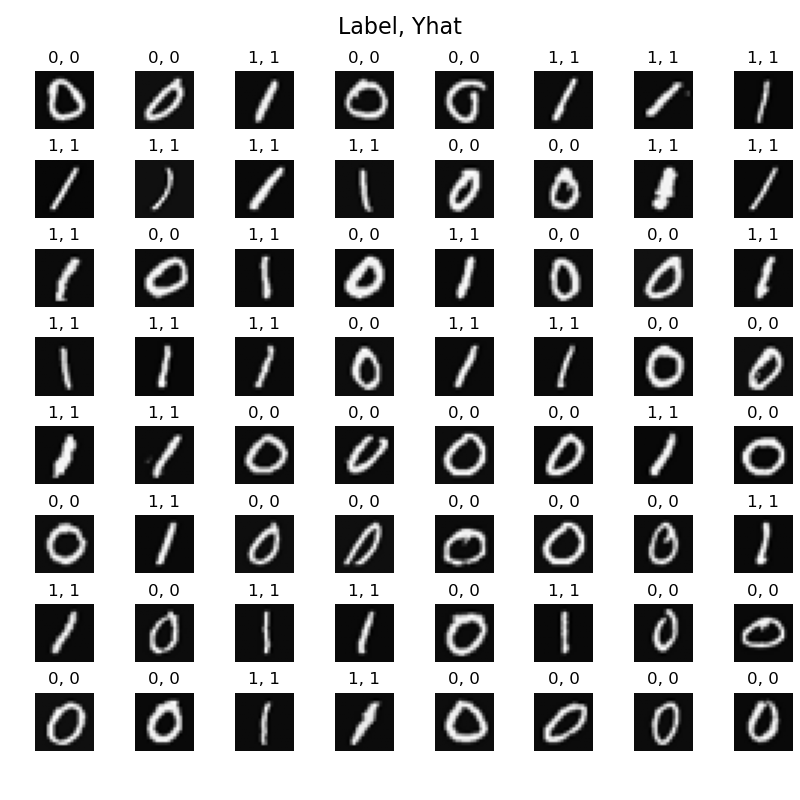

In [33]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# You do not need to modify anything in this cell

m, n = X.shape

fig, axes = plt.subplots(8, 8, figsize=(8, 8))
fig.tight_layout(pad=0.1, rect=[0, 0.03, 1, 0.92]) #[left, bottom, right, top]

for i, ax in enumerate(axes.flat):
    # Select random indices
    random_index = np.random.randint(m)
    
    # Select rows corresponding to the random indices and
    # reshape the image
    X_random_reshaped = X[random_index].reshape((20, 20)).T
    
    # Display the image
    ax.imshow(X_random_reshaped, cmap='gray')
   
    # Display the label above the image
    ax.set_title(f"{y[random_index,0]}, {Yhat[random_index, 0]}")
    ax.set_axis_off() 
fig.suptitle("Label, Yhat", fontsize=16)
plt.show()

你可以看到其中一张分类错误的图像是什么样子。

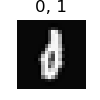

In [34]:
fig = plt.figure(figsize=(1, 1))
errors = np.where(y != Yhat)
random_index = errors[0][0]
X_random_reshaped = X[random_index].reshape((20, 20)).T
plt.imshow(X_random_reshaped, cmap='gray')
plt.title(f"{y[random_index,0]}, {Yhat[random_index, 0]}")
plt.axis('off')
plt.subplots_adjust(top=0.8)
plt.show()

<a name="2.7"></a>
### 2.7 恭喜！
你已成功构建并运用了一个神经网络。

<a name="2.8"></a>
### 2.8 NumPy广播教程（可选）


在上一个示例中，$\mathbf{Z}=\mathbf{XW} + \mathbf{b}$ 使用了NumPy广播来扩展向量 $\mathbf{b}$。如果你不熟悉NumPy广播，这里提供了一个简短教程。
$\mathbf{XW}$ 是一个矩阵 - 矩阵运算，维度为 $(m,j_1)(j_1,j_2)$，结果是一个维度为 $(m,j_2)$ 的矩阵。在此基础上，我们加上一个维度为 $(j_2,)$ 的向量 $\mathbf{b}$。为了使这个逐元素运算有意义，$\mathbf{b}$ 必须扩展为一个 $(m,j_2)$ 的矩阵。这种扩展由NumPy广播为你完成。 



广播适用于逐元素操作。其基本操作是通过复制元素来 “拉伸” 较小的维度，以匹配较大的维度。
更[具体地](https://NumPy.org/doc/stable/user/basics.broadcasting.html)说：在对两个数组进行操作时，NumPy 会逐元素比较它们的形状。它从尾部（即最右边）的维度开始，向左进行比较。当两个维度满足以下条件时是兼容的：
- 它们相等，或者
- 其中一个维度为 1  

如果不满足这些条件，就会抛出 `ValueError: operands could not be broadcast together` 异常，表明数组的形状不兼容。output数组的大小是input数组各轴上不为 1 的大小。

以下是一些示例：

<figure>
    <center> <img src="./images/C2_W1_Assign1_BroadcastIndexes.PNG"  alt='missing' width="400"  ><center/>
    <figcaption>计算广播结果形状</figcaption>
<figure/>

下面的图表描述了不断扩大的维度。请注意下面的红色文字：

<figure>
    <center> <img src="./images/C2_W1_Assign1_Broadcasting.gif"  alt='missing' width="600"  ><center/>
    <figcaption>广播在概念上扩展参数，以匹配逐元素操作</figcaption>
<figure/>

上面的图表展示了NumPy在最终运算之前扩展参数以实现匹配。请注意，这只是概念性描述。NumPy运算的实际机制会选择最有效的实现方式。

对于以下每个示例，在运行示例之前，尝试猜测结果的大小。

In [35]:
a = np.array([1,2,3]).reshape(-1,1)  #(3,1)
b = 5
print(f"(a + b).shape: {(a + b).shape}, \na + b = \n{a + b}")

(a + b).shape: (3, 1), 
a + b = 
[[6]
 [7]
 [8]]


请注意，这适用于所有按元素操作：

In [36]:
a = np.array([1,2,3]).reshape(-1,1)  #(3,1)
b = 5
print(f"(a * b).shape: {(a * b).shape}, \na * b = \n{a * b}")

(a * b).shape: (3, 1), 
a * b = 
[[ 5]
 [10]
 [15]]


<figure>
    <img src="./images/C2_W1_Assign1_VectorAdd.PNG"  alt='missing' width="740" >
    <center><figcaption><b>逐行逐列按元素运算</b></figcaption></center>
<figure/>

In [37]:
a = np.array([1,2,3,4]).reshape(-1,1)
b = np.array([1,2,3]).reshape(1,-1)
print(a)
print(b)
print(f"(a + b).shape: {(a + b).shape}, \na + b = \n{a + b}")

[[1]
 [2]
 [3]
 [4]]
[[1 2 3]]
(a + b).shape: (4, 3), 
a + b = 
[[2 3 4]
 [3 4 5]
 [4 5 6]
 [5 6 7]]


这就是你在上面构建的全连接层中的情况。将一个一维向量 $b$ 加到一个 $(m,j)$ 矩阵上。
<figure>
    <img src="./images/C2_W1_Assign1_BroadcastMatrix.PNG"  alt='missing' width="740" >
    <center><figcaption><b>矩阵 + 一维向量</b></figcaption></center>
<figure/>